# Multiple Seasonal-Trend decomposition using LOESS (MSTL)

Many real series have **more than one** seasonal pattern at once (e.g. hourly
electricity demand: a daily cycle *and* a weekly cycle).  Classical STL only
handles a single period.  **MSTL** extends STL by iteratively extracting
several seasonal components, then returning a shared trend and residual.

$$
y_t
= S_t^{(1)} + S_t^{(2)} + \cdots + S_t^{(m)}
+ T_t + R_t.
$$

**Reference**

> K. Bandara, R. J. Hyndman, C. Bergmeir.  
> *MSTL: A Seasonal-Trend Decomposition Algorithm for Time Series with
Multiple Seasonal Patterns.* arXiv:2107.13462, 2021.

Important clarifications:

- “Multiple” here means **multiple seasonal periods on one univariate
  series**, not a multivariate / multi-channel decomposer.
- The PySDKit implementation (`pysdkit.tsa.MSTL`) is self-contained and
  builds on the local `STL` class — **no Statsmodels dependency**.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import MSTL, STL

print(MSTL(periods=(24, 168)))

Multiple Seasonal-Trend decomposition using LOESS (MSTL)(periods=(24, 168), windows=None, lmbda=None, iterate=2)


## 2. Algorithm principles

### 2.1 Nested loops

Given periods $p_1 < p_2 < \cdots < p_m$ (always sorted ascending):

```
deseas ← y
seasonal[i] ← 0
for j = 1 … iterate:                 # outer refinement
    for i = 1 … m:                   # inner: short → long period
        deseas ← deseas + seasonal[i]
        fit ← STL(deseas, period=p_i, seasonal=window_i)
        seasonal[i] ← fit.seasonal
        deseas ← deseas - seasonal[i]
trend ← fit.trend                    # from the last STL call
resid ← deseas - trend
```

Re-adding `seasonal[i]` before each STL call is essential: it stops a longer
seasonality from permanently absorbing a shorter one.

### 2.2 Default seasonal windows

Following Bandara et al. (Appendix A),

$$
\texttt{windows}_i = 7 + 4\, i,\qquad i = 1,\ldots,m
$$

(e.g. two seasons → `(11, 15)`).  Larger windows make each seasonal component
vary more slowly across seasons.

### 2.3 Optional Box-Cox

`lmbda=None` (default) leaves the series unchanged; a float applies a fixed
Box-Cox transform; `"auto"` estimates λ by MLE (data must be strictly
positive).

## 3. Toy example — daily + weekly seasonality

Hourly-style synthetic data with periods 24 and $24\times 7 = 168$.

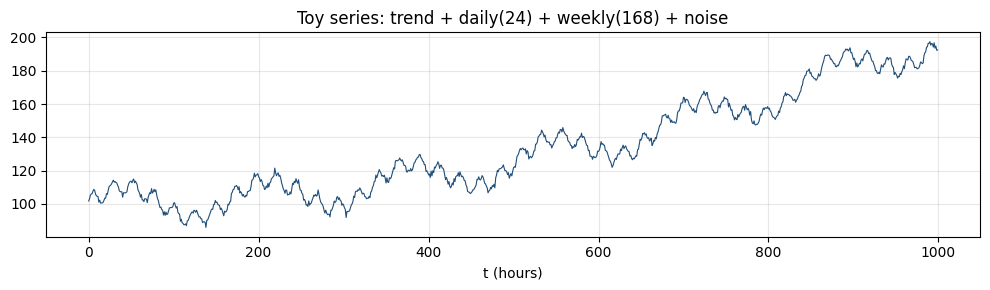

In [2]:
rng = np.random.default_rng(0)
n = 1000
t = np.arange(1, n + 1)

daily = 5 * np.sin(2 * np.pi * t / 24)
weekly = 10 * np.sin(2 * np.pi * t / (24 * 7))
trend = 0.0001 * t**2 + 100
noise = rng.standard_normal(n)
y = trend + daily + weekly + noise

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(y, color="#1f4e79", lw=0.8)
ax.set_title("Toy series: trend + daily(24) + weekly(168) + noise")
ax.set_xlabel("t (hours)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Run MSTL

In [3]:
mstl = MSTL(periods=(24, 24 * 7), iterate=2)
res = mstl.fit_transform(y)

print("periods:", res.periods)
print("seasonal shape:", res.seasonal.shape)  # (2, n)
print("trend shape:   ", res.trend.shape)
recon = res.seasonal.sum(0) + res.trend + res.resid
print("max |reconstruction error|:", np.max(np.abs(res.observed - recon)))

periods: (24, 168)
seasonal shape: (2, 1000)
trend shape:    (1000,)
max |reconstruction error|: 5.684341886080802e-14


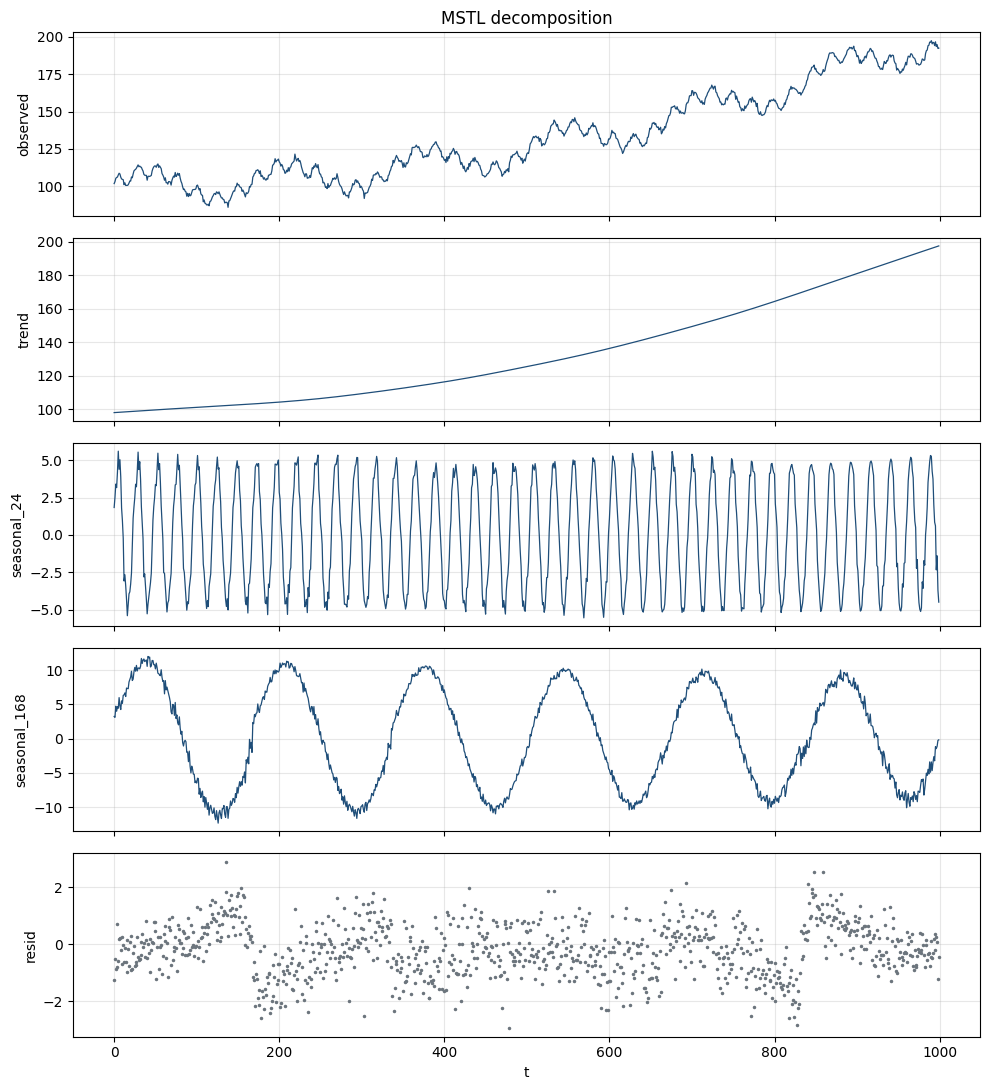

In [4]:
def plot_mstl(result, title="MSTL decomposition"):
    rows = [("observed", result.observed), ("trend", result.trend)]
    seas = result.seasonals
    for i, p in enumerate(result.periods):
        rows.append((f"seasonal_{p}", seas[i]))
    rows.append(("resid", result.resid))

    fig, axes = plt.subplots(len(rows), 1, figsize=(10, 2.2 * len(rows)), sharex=True)
    for ax, (name, series) in zip(axes, rows):
        if name == "resid":
            ax.plot(series, marker="o", ms=1.5, ls="none", color="#6c757d")
        else:
            ax.plot(series, color="#1f4e79", lw=0.9)
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
    axes[0].set_title(title)
    axes[-1].set_xlabel("t")
    plt.tight_layout()
    return fig


plot_mstl(res)
plt.show()

### 3.2 Compare extracted seasonals with the ground truth

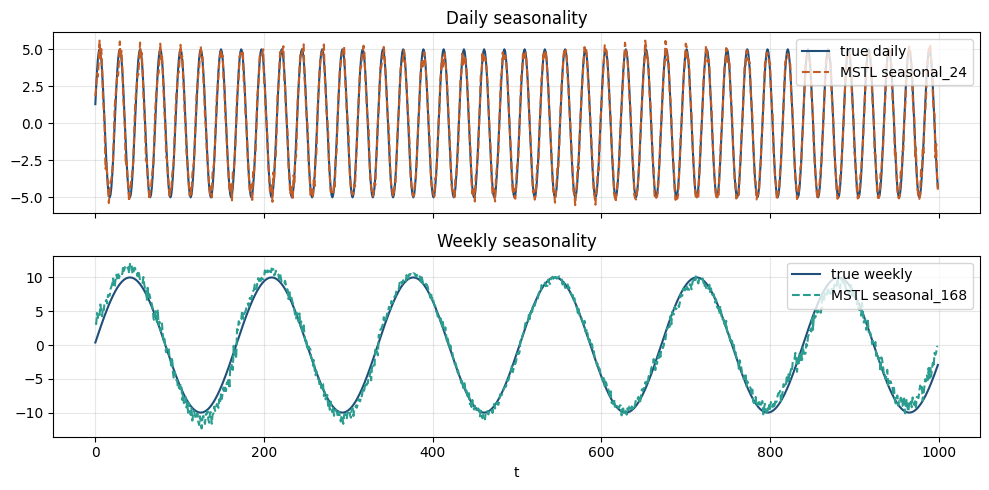

corr daily : 0.9938259202665535
corr weekly: 0.9908922714951066
corr trend : 0.9998378684894604


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(daily, label="true daily", color="#1f4e79")
axes[0].plot(res.seasonal[0], ls="--", label="MSTL seasonal_24", color="#c45c26")
axes[0].legend(loc="upper right")
axes[0].set_title("Daily seasonality")

axes[1].plot(weekly, label="true weekly", color="#1f4e79")
axes[1].plot(res.seasonal[1], ls="--", label="MSTL seasonal_168", color="#2a9d8f")
axes[1].legend(loc="upper right")
axes[1].set_title("Weekly seasonality")
axes[1].set_xlabel("t")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("corr daily :", np.corrcoef(res.seasonal[0], daily)[0, 1])
print("corr weekly:", np.corrcoef(res.seasonal[1], weekly)[0, 1])
print("corr trend :", np.corrcoef(res.trend, trend)[0, 1])

## 4. Why not a single STL?

Fitting ordinary STL with only `period=24` folds weekly energy into the
remainder (or pollutes the trend).  MSTL keeps both cycles explicit.

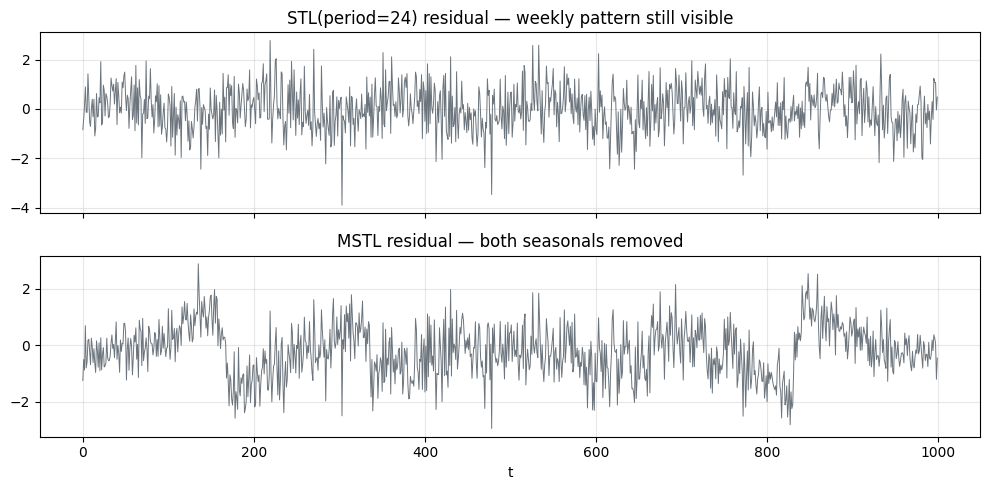

STL residual std : 0.8929189678219497
MSTL residual std: 0.920043596403007


In [6]:
stl_only = STL(period=24, seasonal=11).fit_transform(y)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(stl_only.resid, color="#6c757d", lw=0.7)
axes[0].set_title("STL(period=24) residual — weekly pattern still visible")
axes[1].plot(res.resid, color="#6c757d", lw=0.7)
axes[1].set_title("MSTL residual — both seasonals removed")
axes[1].set_xlabel("t")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("STL residual std :", stl_only.resid.std())
print("MSTL residual std:", res.resid.std())

## 5. Custom windows & STL kwargs

Any STL option other than `period` / `seasonal` can be forwarded through
`stl_kwargs` (e.g. `robust`, `seasonal_deg`, `trend`).

In [7]:
res_custom = MSTL(
    periods=(24, 168),
    windows=(11, 15),
    iterate=2,
    stl_kwargs={"seasonal_deg": 0, "robust": False},
).fit_transform(y)

print("custom periods:", res_custom.periods)
print(
    "reconstruction ok:",
    np.allclose(
        res_custom.observed,
        res_custom.seasonal.sum(0) + res_custom.trend + res_custom.resid,
    ),
)

custom periods: (24, 168)
reconstruction ok: True


## 6. API summary

```python
from pysdkit import MSTL

mstl = MSTL(
    periods=(24, 168),
    windows=None,          # default: (11, 15)
    lmbda=None,            # or float / "auto"
    iterate=2,
    stl_kwargs={"robust": True},
)
res = mstl.fit_transform(y)
# res.observed, res.seasonal (m, n), res.trend, res.resid, res.periods
```

## 7. Takeaways

- MSTL = repeated STL over several periods, refined for `iterate` outer loops.
- Always pass periods from short to long (the class sorts them for you).
- Default seasonal windows `(11, 15, …)` come from the MSTL paper.
- Prefer MSTL over plain STL whenever more than one seasonal length is present.